### Stabilisasi dalam Norm $\infty$

Pendekatan langsung untuk menunjukkan bahwa $||E||_\infty \rightarrow 0$ saat $\Delta x \rightarrow 0$ adalah dengan menggunakan batasan matriks

$$
    ||E||_\infty \leq \frac{1}{\sqrt{\Delta x}} ||E||_2.
$$

Untuk masalah contoh kita, kita menunjukkan bahwa $||E||_2 = \mathcal{O}(\Delta x^2)$, jadi ini menyiratkan bahwa setidaknya kita tahu bahwa $||E||_\infty = \mathcal{O}(\Delta x^{3/2})$. Ini tidak menguntungkan karena kita mengharapkan $||E||_\infty = \mathcal{O}(\Delta x^2)$ karena diskritisasi. Untuk mengurangi masalah ini, mari kita kembali dan mempertimbangkan definisi stabilitas kita, tetapi kali ini mempertimbangkan norm $\infty$.

Matriks $A$ kita dapat dipandang sebagai sejumlah pendekatan diskrit untuk *fungsi Green* di setiap kolomnya. Ini lebih luas penerapannya nanti, jadi kita akan meluangkan waktu untuk mengulas teori fungsi Green dan menerapkannya pada masalah contoh sederhana kita.

### Fungsi Green

Pertimbangkan masalah nilai batas (BVP) dengan kondisi batas Dirichlet

$$
    u''(x) = f(x) \quad \Omega = [0, 1] \\
    u(0) = \alpha \quad u(1) = \beta.
$$

Pilih suatu titik tetap $\bar{x} \in \Omega$, fungsi Green $G(x ; \bar{x})$ menyelesaikan masalah nilai batas di atas dengan

$$
    f(x) = \delta(x - \bar{x})
$$

dan $\alpha = \beta = 0$. Anda bisa menganggap ini sebagai hasil dari masalah keadaan tunak dari persamaan panas dengan kehilangan panas titik di suatu tempat dalam domain.

Untuk menemukan fungsi Green untuk masalah kita, kita dapat mengintegrasi di sekitar titik $\bar{x}$ dekat sumber fungsi delta untuk menemukan

$$
\begin{aligned}
    \int^{\bar{x} + \epsilon}_{\bar{x} - \epsilon} u''(x) dx &= \int^{\bar{x} + \epsilon}_{\bar{x} - \epsilon} \delta(x - \bar{x}) dx \\
    u'(\bar{x} + \epsilon) - u'(\bar{x} - \epsilon) &= 1
\end{aligned}
$$

Mengingat bahwa berdasarkan definisi, integral dari fungsi $\delta$ harus bernilai 1 jika interval integrasi mencakup $\bar{x}$. Kita melihat bahwa loncatan dalam turunan pada $\bar{x}$ dari kiri dan kanan harus bernilai 1.

Setelah beberapa aljabar, kita dapat menyelesaikan fungsi Green untuk model BVP kita sebagai

$$
    G(x; \bar{x}) = \left \{ \begin{aligned}
        (\bar{x} - 1) x & & 0 \leq x \leq \bar{x} \\
        \bar{x} (x - 1) & & \bar{x} \leq x \leq 1
    \end{aligned} \right .
$$

Salah satu sifat penting dari PDE linear (atau ODE) secara umum adalah mereka menunjukkan prinsip superposisi. Alasan kita peduli dengan ini dalam fungsi Green adalah bahwa jika kita memiliki $f(x)$ yang terdiri dari dua fungsi $\delta$, ternyata solusi adalah jumlah dari dua fungsi Green yang bersesuaian. Misalnya, jika

$$
    f(x) = \delta(x - 0.25) + 2 \delta(x - 0.5)
$$

maka

$$
    u(x) = G(x ; 0.25) + 2 G(x ; 0.5).
$$

Tentu, ini tentu saja dapat diperluas ke sejumlah tak terhingga fungsi $\delta$, sehingga

$$
    f(x) = \int^1_0 f(\bar{x}) \delta(x - \bar{x}) d\bar{x}
$$

dan oleh karena itu

$$
    u(x) = \int^1_0 f(\bar{x}) G(x ; \bar{x}) d\bar{x}.
$$

Untuk mengakomodasi efek dari kondisi batas, kita dapat terus menambahkan fungsi Green ke dalam solusi untuk menemukan solusi umum dari BVP asli kita sebagai

$$
    u(x) = \alpha (1 - x) + \beta x + \int^1_0 f(\bar{x}) G(x ; \bar{x}) d\bar{x}.
$$

Jadi, mengapa kita melakukan semua ini? Nah, representasi solusi fungsi Green di atas dapat dianggap sebagai operator linear pada fungsi $f(x)$. Ditulis dalam istilah yang mungkin lebih familiar, kita memiliki

$$
    \mathcal{A} u = f \quad u = \mathcal{A}^{-1} f.
$$

Sekarang kita melihat bahwa operator linear $\mathcal{A}$ kita mungkin merupakan analog kontinu dari matriks diskrit $A$ kita.

Untuk melanjutkan, kita akan memodifikasi matriks $A$ asli kita menjadi versi yang sedikit berbeda berdasarkan diskritisasi yang sama. Alih-alih memindahkan suku batas ke sisi kanan persamaan, kita akan memperkenalkan dua "nilai tak dikenal" baru, yang disebut *ghost cells*, yang akan ditempatkan di tepi grid. Kita akan memberi label pada sel-sel ini dengan $U_0$ dan $U_{m+1}$. Sebenarnya, kita tahu nilai dari titik-titik ini, yaitu kondisi batas!

Sistem yang dimodifikasi kemudian terlihat seperti ini:

$$
    A = \frac{1}{\Delta x^2} \begin{bmatrix}
        \Delta x^2 & 0  \\
        1 & -2 & 1 \\
          &  1 & -2 & 1 \\
          &    & \ddots & \ddots & \ddots \\
          &    &        &      1 &     -2 & 1 \\
          &    &        &        &      1 & -2 & 1 \\
          &    &        &        &        &  0 & \Delta x^2
    \end{bmatrix}
    \quad \quad 
    U = \begin{bmatrix}
        U_0 \\
        U_1 \\
        \vdots \\
        U_m \\
        U_{m+1}
    \end{bmatrix}
    \quad \quad
    F = \begin{bmatrix}
        \alpha \\
        f(x_1) \\
        \vdots \\
        f(x_{m}) \\
        \beta
    \end{bmatrix}
$$

Ini memiliki keuntungan bahwa kita dapat mengimplementasikan kondisi batas yang lebih umum dan mengisolasi ketergantungan aljabar pada kondisi batas. Kekurangannya adalah bahwa matriks ini tidak lagi memiliki bentuk yang sesederhana sebelumnya.

Akhirnya, mari kita beralih ke bentuk dari matriks $A^{-1}$. Memperkenalkan sedikit notasi lebih lanjut, misalkan $A_{j}$ menunjukkan kolom ke-$j$ dan $A_{ij}$ menunjukkan elemen ke-$i, j$ dari matriks $A$.

Kita tahu bahwa

$$
    A A^{-1}_j = e_j
$$

di mana $e_j$ adalah vektor satuan dengan nilai 1 pada baris ke-$j$ (kolom ke-$j$ dari matriks identitas).

Perhatikan bahwa sistem di atas memiliki beberapa kesamaan dengan versi diskrit dari masalah fungsi Green. Di sini, $e_j$ mewakili fungsi $\delta$, $A$ adalah operator asli, dan $A^{-1}_j$ adalah efek yang ditimbulkan oleh fungsi $\delta$ ke-$j$ (yang sesuai dengan $\bar{x}$) terhadap solusi penuh.

Ternyata kita dapat menuliskan matriks invers langsung menggunakan fungsi Green (lihat LeVeque untuk detailnya), tetapi kita akhirnya mendapatkan

$$
    A^{-1}_{ij} = \Delta x G(x_i ; x_j) = \left \{ \begin{aligned}
        \Delta x (x_j - 1) x_i, & & i &= 1,2, \ldots j \\
        \Delta x (x_i - 1) x_j, & & i &= j, j+1, \ldots , m
    \end{aligned} \right .
$$

Kita juga dapat menuliskan sisi kanan yang efektif dari sistem kita sebagai

$$
    F = \alpha e_0 + \beta e_{m+1} + \sum^m_{j=1} f_j e_j
$$

dan akhirnya solusi sebagai

$$
    U = \alpha A^{-1}_{0} + \beta A^{-1}_{m+1} + \sum^m_{j=1} f_j A^{-1}_{j}
$$

yang elemen-elemennya adalah

$$
    U_i = \alpha(1 - x_i) + \beta x_i + \Delta x \sum^m_{j=1} f_j G(x_i ; x_j).
$$

Baiklah, apa yang telah kita dapatkan dari semua ini? Nah, karena kita sekarang tahu bentuk dari $A^{-1}$, kita mungkin dapat mencari norma $\infty$ dari matriks ini. Ingat bahwa norma $\infty$ dari suatu matriks (yang diinduksi dari norma $\infty$) untuk suatu vektor adalah

$$
    || C ||_\infty = \max_{0 \leq i \leq m+1} \sum^{m+1}_{j=0} |C_{ij}|.
$$

Perhatikan bahwa karena bentuk matriks $A^{-1}$, jumlah dari baris pertama adalah

$$
    \sum^{m+1}_{j=0} A_{0j}^{-1} = 1
$$

begitu juga dengan baris terakhir $A^{-1}_{m+1}$. Kita juga tahu bahwa untuk baris lainnya, $A^{-1}_{i,0} < 1$ dan $A^{-1}_{i,m+1} < 1$.

Baris-baris antara juga semuanya terbatas dengan

$$
    \sum^{m+1}_{j=0} |A^{-1}_{ij}| \leq 1 + 1 + m \Delta x < 3
$$

dengan menggunakan fakta bahwa kita tahu

$$
    \Delta x = \frac{1}{m+1}.
$$

Ini menyelesaikan penjelajahan stabilitas kita karena sekarang kita dapat dengan tegas mengatakan bahwa

$$
    ||A^{-1}||_\infty < 3 \quad \forall \Delta x.
$$

## Kondisi Batas Neumann

Seperti yang telah disebutkan sebelumnya, kita dapat memasukkan jenis kondisi batas lain ke dalam diskritisasi kita dengan menggunakan versi modifikasi dari matriks kita. Mari kita coba melakukan ini untuk masalah awal kita, tetapi dengan salah satu sisi yang memiliki kondisi batas Neumann:

$$
    u''(x) = f(x) \quad \Omega = [-1, 1] \\
    u(-1) = \alpha \quad u'(1) = \sigma.
$$

**Latihan**

$$
    u''(x) = f(x) \quad \Omega = [-1, 1] \\
    u(-1) = \alpha \quad u'(1) = \sigma.
$$

$$
    u(x) = -(5 + e) x - (2 + e + e^{-1}) + e^x
$$

Eksplorasi penerapan kondisi batas Neumann dengan

1. menggunakan ekspresi satu sisi orde pertama,
2. menggunakan ekspresi terpusat orde kedua, dan
3. menggunakan ekspresi satu sisi orde kedua.


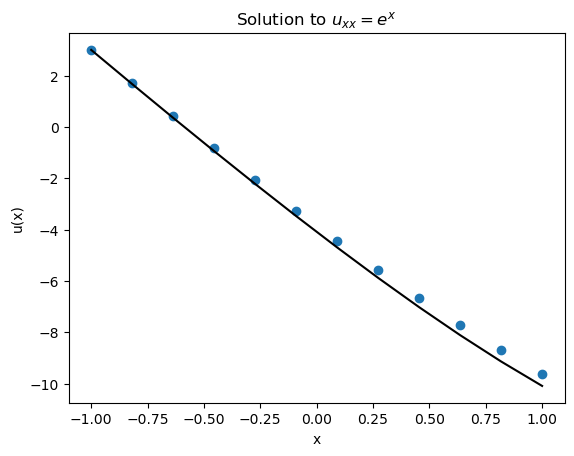

In [3]:
import numpy as numpy
import matplotlib.pyplot as plt

def solve_mixed_1st_order_one_sided(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)

    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)

    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = 1.0 / (delta_x)
    A[-1, -2] = -1.0 / (delta_x)

    b[0] = alpha
    b[-1] = sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U


u_true = lambda x: -(5.0 + numpy.exp(1.0)) * x - (2.0 + numpy.exp(1.0) + numpy.exp(-1.0)) + numpy.exp(x)

x_bc, U = solve_mixed_1st_order_one_sided(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

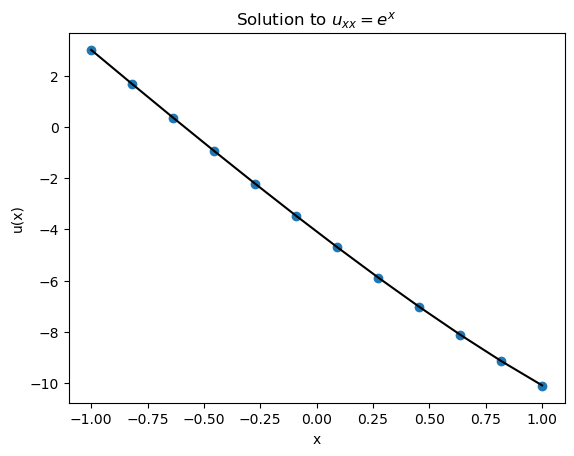

In [4]:
import numpy as numpy
import matplotlib.pyplot as plt


def solve_mixed_2nd_order_centered(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)

    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)

    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = -1.0 / (delta_x)
    A[-1, -2] =  1.0 / (delta_x)

    b[0] = alpha
    b[-1] = delta_x / 2.0 * f(x_bc[-1]) - sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U

x_bc, U = solve_mixed_2nd_order_centered(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

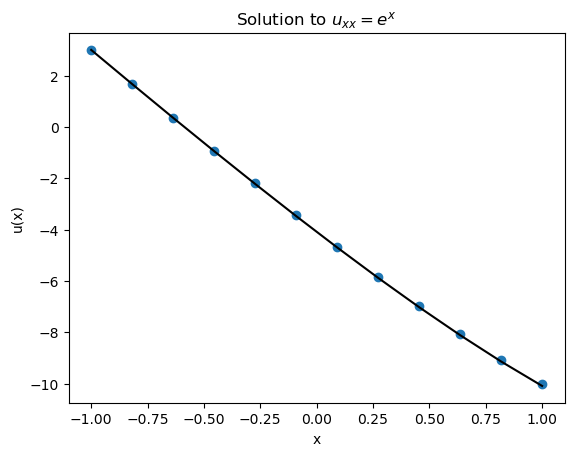

In [5]:
import numpy as numpy
import matplotlib.pyplot as plt

def solve_mixed_2nd_order_one_sided(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)
    
    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)
    
    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = 3.0 / (2.0 * delta_x)
    A[-1, -2] = -4.0 / (2.0 * delta_x)
    A[-1, -3] = 1.0 / (2.0 * delta_x)

    b[0] = alpha
    b[-1] = sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U

x_bc, U = solve_mixed_2nd_order_one_sided(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

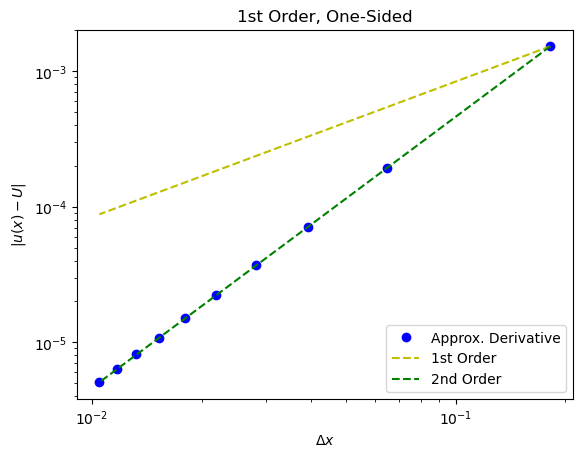

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Problem setup
a = -1.0
b = 1.0

f = lambda x: np.exp(x)

u_true = lambda x: -(5.0 + np.exp(1.0))*x - (2.0 + np.exp(1.0) + np.exp(-1.0)) + np.exp(x)

# ----------------------------
# Solver sederhana
# ----------------------------

def solver(m):

    x = np.linspace(a,b,m+2)
    dx = (b-a)/(m+1)

    A = np.zeros((m+2,m+2))
    rhs = np.zeros(m+2)

    for i in range(1,m+1):
        A[i,i-1] = 1/dx**2
        A[i,i] = -2/dx**2
        A[i,i+1] = 1/dx**2
        rhs[i] = f(x[i])

    A[0,0] = 1
    A[-1,-1] = 1

    rhs[0] = u_true(x[0])
    rhs[-1] = u_true(x[-1])

    U = np.linalg.solve(A,rhs)

    return x,U


# ----------------------------
# Error vs Delta x
# ----------------------------

m_range = np.arange(10,200,20)

delta_x = np.zeros(len(m_range))
error = np.zeros(len(m_range))

for i,m in enumerate(m_range):

    x,U = solver(m)

    delta_x[i] = (b-a)/(m+1)

    error[i] = np.linalg.norm(U - u_true(x),ord=np.inf)


# ----------------------------
# Plot log-log
# ----------------------------

fig = plt.figure()
ax = fig.add_subplot(111)

# titik hitam
ax.loglog(delta_x,error,'bo',label="Approx. Derivative")

# garis orde 1
C1 = error[0]/delta_x[0]
ax.loglog(delta_x,C1*delta_x,'y--',label="1st Order")

# garis orde 2
C2 = error[0]/delta_x[0]**2
ax.loglog(delta_x,C2*delta_x**2,'g--',label="2nd Order")

ax.set_xlabel(r"$\Delta x$")
ax.set_ylabel(r"$|u(x)-U|$")
ax.set_title("1st Order, One-Sided")

ax.legend(loc=4)

plt.show()

## Eksistensi dan Unikitas

Salah satu pertanyaan yang perlu diajukan sebelum memulai solusi numerik untuk suatu persamaan adalah apakah persamaan asli tersebut *well-posed*. Well-posedness didefinisikan sebagai masalah yang memiliki solusi unik dan bergantung secara kontinu pada data input (misalnya kondisi awal dan kondisi batas).

Pertimbangkan BVP yang telah kita eksplorasi tetapi sekarang tambahkan kondisi batas Neumann yang ketat:

$$
    u''(x) = f(x) \quad \Omega = [0, 1] \\
    u'(0) = \sigma_0 \quad u'(1) = \sigma_1.
$$

Kita dapat dengan mudah mendiskretisasikan ini menggunakan salah satu metode yang telah kita kembangkan di atas, tetapi kita akan menemui masalah.


In [9]:
import numpy as numpy
import matplotlib.pyplot as plt


# Problem setup
a = -1.0
b = 1.0
alpha = 3.0
sigma = -5.0
f = lambda x: numpy.exp(x)

# Descretization
m = 50
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Construct matrix A
A = numpy.zeros((m + 2, m + 2))
diagonal = numpy.ones(m + 2) / delta_x**2
A += numpy.diag(diagonal * -2.0, 0)
A += numpy.diag(diagonal[:-1], 1)
A += numpy.diag(diagonal[:-1], -1)

# Construct RHS
b = f(x_bc)

# Boundary conditions
A[0, 0] = -1.0 / delta_x
A[0, 1] = 1.0 / delta_x
A[-1, -1] = -1.0 / (delta_x)
A[-1, -2] =  1.0 / (delta_x)

b[0] = delta_x / 2.0 * f(x_bc[0]) - alpha
b[-1] = delta_x / 2.0 * f(x_bc[-1]) - sigma

# Solve system
try:
    U = numpy.linalg.solve(A, b)
except numpy.linalg.LinAlgError as e:
    print(e)
    import traceback
    traceback.print_exc()

Singular matrix


Traceback (most recent call last):
  File "C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10668\4182703023.py", line 39, in <module>
    U = numpy.linalg.solve(A, b)
  File "c:\Users\LENOVO\.conda\envs\geomath\Lib\site-packages\numpy\linalg\_linalg.py", line 410, in solve
    r = gufunc(a, b, signature=signature)
  File "c:\Users\LENOVO\.conda\envs\geomath\Lib\site-packages\numpy\linalg\_linalg.py", line 104, in _raise_linalgerror_singular
    raise LinAlgError("Singular matrix")
numpy.linalg.LinAlgError: Singular matrix


Kita dapat melihat mengapa $A$ singular, vektor konstan $e = [1, 1, 1, 1, 1, \ldots, 1]^T$ sebenarnya berada di ruang nol dari $A$. Metode numerik kita sebenarnya telah menunjukkan bahwa masalah ini *ill-posed*! Memang, karena kondisi batas hanya pada turunan, terdapat sejumlah solusi tak terhingga untuk BVP ini (hal ini juga bisa terjadi jika tidak ada solusi).

Cara lain untuk memahami mengapa ini terjadi adalah dengan memeriksa masalah ini sekali lagi sebagai masalah keadaan tunak yang berasal dari persamaan panas. Pertimbangkan persamaan panas dengan $\sigma\_0 = \sigma\_1 = 0$ dan $f(x) = 0$. Pengaturan ini akan mempertahankan panas di batang karena tidak ada panas yang bisa keluar dari ujung-ujung batang. Faktanya, solusi untuk masalah keadaan tunak ini hanya akan mendistribusikan panas di batang secara merata berdasarkan kondisi awal. Kita kemudian akan mendapatkan solusi

$$
    u(x) = \int^1_0 u^0(x) dx = C.
$$

Masalahnya berasal dari kenyataan bahwa masalah keadaan tunak tidak mengetahui informasi ini dengan sendirinya. Ini berarti bahwa BVP seperti yang ada dapat memilih sembarang nilai \$C\$ dan itu akan tetap menjadi solusi.

Solusinya serupa jika kita memiliki pengaturan yang sama kecuali \$f(x) \neq 0\$. Sekarang kita mungkin menambah atau mengurangi panas di batang. Dalam kasus ini, mungkin tidak ada keadaan tunak sama sekali! Anda sebenarnya bisa menunjukkan bahwa jika penambahan dan pengurangan panas saling membatalkan dengan tepat, kita mungkin memang memiliki solusi jika

$$
    \int^1_0 f(x) dx = 0
$$

yang sekali lagi mengarah pada jumlah solusi yang tak terhingga.


## Diskritisasi Umum untuk Persamaan Diferensial Orde Kedua Linier

Mari sekarang kita jelaskan metode untuk menyelesaikan persamaan

$$
    a(x) u''(x) + b(x) u'(x) + c(x) u(x) = f(x) \quad \Omega = [a, b] \\
    u(a) = \alpha \quad u(b) = \beta.
$$

Coba diskretisasi ini menggunakan perbedaan hingga orde kedua dan tulis sistemnya untuk:

$$
    a(x) u''(x) + b(x) u'(x) + c(x) u(x) = f(x) \quad \Omega = [a, b] \\
    u(a) = \alpha \quad u(b) = \beta.
$$

Pendekatan beda hingga orde kedua yang umum untuk persamaan di atas dapat ditulis sebagai

$$
    a_i \frac{U_{i+1} - 2 U_i + U_{i-1}}{\Delta x^2} + b_i \frac{U_{i+1} - U_{i-1}}{2 \Delta x} + c_i U_i = f_i
$$

yang menghasilkan entri-entri matriks

$$
    A_{i,i} = -\frac{2 a_i}{\Delta x^2} + c_i
$$

pada diagonal dan

$$
    A_{i,i\pm1} = \frac{a_i}{\Delta x^2} \pm \frac{b_i}{2 \Delta x}
$$

pada sub-diagonal. Kita dapat menangani kondisi batas dengan menggunakan pendekatan titik hantu atau dengan menggabungkannya ke dalam evaluasi sisi kanan.


### Contoh:

Pertimbangkan masalah konduksi panas keadaan tunak dengan $\kappa(x)$ yang bervariasi, sehingga persamaannya menjadi

$$
    (\kappa(x) u'(x))' = f(x), \quad \Omega = [0, 1]
$$

dengan kondisi batas

$$
    u(0) = \alpha \quad u(1) = \beta
$$

Dalam kasus ini, kita memiliki persamaan diferensial dengan koefisien yang bervariasi, di mana $\kappa(x)$ berfungsi sebagai koefisien konduksi termal yang bergantung pada posisi $x$.

Dengan menggunakan aturan rantai, kita tahu bahwa

$$
    \kappa(x) u''(x) + \kappa'(x) u'(x) = f(x).
$$

Ternyata dalam kasus ini pendekatan ini bukanlah pendekatan terbaik untuk menyelesaikan masalah. Dalam banyak kasus, lebih baik untuk mendiskretisasi bentuk asli dari fisika daripada formulasi yang mungkin setara. Untuk menunjukkan hal ini, mari kita coba membangun sistem untuk menyelesaikan persamaan asli

$$
    (\kappa(x) u'(x))' = f(x).
$$

Pertama, kita akan mendekati ekspresi

$$
    \kappa(x) u'(x)
$$

tetapi pada titik setengah jalan antara titik $x_i$, yaitu $x_{i + 1/2}$.

Kita juga akan menganggap pendekatan ini efektif sebesar $\Delta x / 2$ dan menemukan

$$
    \kappa(x_{i+1/2}) u'(x_{i+1/2}) = \kappa_{i+1/2} \frac{U_{i+1} - U_i}{\Delta x}.
$$

Sekarang dengan mengambil pendekatan ini dan mengurangkannya dengan beda yang sama yang terpusat pada \$x\_{i-1/2}\$, kita memperoleh

$$
\begin{aligned}
    (\kappa(x_i) u'(x_i))' &= \frac{1}{\Delta x} \left [ \kappa_{i+1/2} \frac{U_{i+1} - U_i}{\Delta x} - \kappa_{i-1/2} \frac{U_{i} - U_{i-1}}{\Delta x} \right ] \\
    &= \frac{\kappa_{i+1/2}U_{i+1} - \kappa_{i+1/2} U_i -\kappa_{i-1/2} U_{i} + \kappa_{i-1/2} U_{i-1}}{\Delta x^2} \\
    &= \frac{\kappa_{i+1/2}U_{i+1} - (\kappa_{i+1/2} - \kappa_{i-1/2}) U_i + \kappa_{i-1/2} U_{i-1}}{\Delta x^2}
\end{aligned}
$$

Perlu dicatat bahwa formulasi-formulasi ini sebenarnya setara hingga $\mathcal{O}(\Delta x^2)$. Entri-entri matriksnya adalah

$$
\begin{aligned}
    A_{i,i} = -\frac{\kappa_{i+1/2} - \kappa_{i-1/2}}{\Delta x^2} \\
    A_{i,i \pm 1} = \frac{\kappa_{i\pm 1/2}}{\Delta x^2}.
\end{aligned}
$$

Perlu dicatat bahwa diskretisasi yang terakhir ini bersifat simetris. Hal ini akan berpengaruh terhadap seberapa baik atau seberapa cepat kita dapat menyelesaikan sistem persamaan linear yang dihasilkan.


## Persamaan Non-Linear

Masalah model kita sebelumnya, yaitu persamaan Poisson, adalah sebuah masalah nilai batas (BVP) linear. Bagaimana kita akan mendekati suatu masalah yang bersifat non-linear? Sebagai model masalah baru, mari kita pertimbangkan masalah pendulum non-linear. Sistem fisiknya adalah sebuah massa $m$ yang terhubung pada batang kaku tanpa massa dengan panjang $L$, yang diizinkan untuk berayun pada suatu titik. Sudut $\theta(t)$ diambil terhadap titik setimbang saat massa menggantung ke bawah.

Sistem ini dapat dideskripsikan dengan

$$
    \theta''(t) = \frac{-g}{L} \sin(\theta(t)).
$$

Untuk kemudahan, kita akan mengambil $\frac{g}{L} = 1$.

Dengan melihat deret Taylor dari $\sin$, kita dapat mendekati persamaan ini untuk $\theta$ yang kecil sebagai

$$
    \sin(\theta) \approx \theta - \frac{\theta^3}{6} + \mathcal{O}(\theta^5)
$$

sehingga

$$
    \theta'' = -\theta.
$$

Kita tahu bahwa persamaan ini memiliki solusi dalam bentuk

$$
    \theta(t) = C_1 \cos t + C_2 \sin t.
$$

Jelas kita memerlukan dua kondisi batas untuk menentukan sistem secara unik, yang bisa sedikit merepotkan mengingat biasanya kita menetapkannya pada dua titik dalam domain spasial. Karena kita berada dalam domain waktu, kita dapat menentukan posisi awal pendulum $\theta(0) = \alpha$, namun kondisi kedua akan menyatakan posisi pendulum pada suatu waktu di masa depan, misalnya $\theta(T) = \beta$. Kita juga bisa menentukan kondisi awal lainnya seperti kecepatan sudut $\theta'(0) = \sigma$.


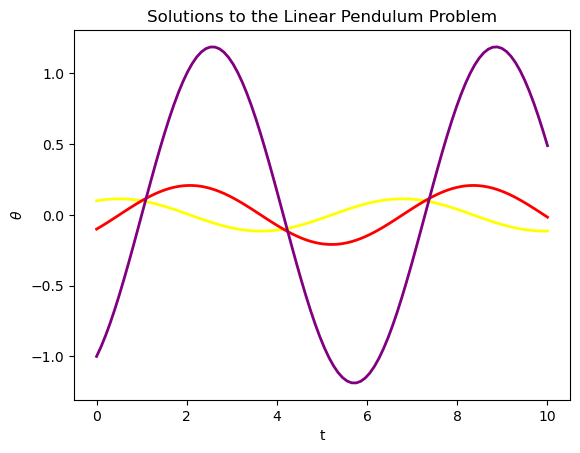

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Linear pendulum function
def linear_pendulum(t, alpha=0.01, beta=0.01, T=1.0):
    C1 = alpha
    C2 = (beta - alpha * np.cos(T)) / np.sin(T)
    return C1 * np.cos(t) + C2 * np.sin(t)

# Parameter
alpha = [0.1, -0.1, -1.0]
beta = [0.1, 0.1, 0.0]
T = [1.0, 1.0, 1.0]

t = np.linspace(0, 10.0, 100)

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Warna garis yang diinginkan
colors = ['yellow', 'red', 'purple']

for i in range(len(alpha)):
    axes.plot(t, linear_pendulum(t, alpha[i], beta[i], T[i]), color=colors[i], linewidth=2)

axes.set_title("Solutions to the Linear Pendulum Problem")
axes.set_xlabel("t")
axes.set_ylabel(r"$\theta$")

plt.show()

Tapi bagaimana kita akan menangani masalah yang sepenuhnya non-linear? Pertama, mari kita lakukan diskretisasi menggunakan pendekatan yang telah kita gunakan sejauh ini, yaitu pendekatan beda hingga orde dua terpusat untuk turunan kedua, sehingga diperoleh

$$
    \frac{1}{\Delta t^2}(\theta_{i+1} - 2 \theta_i + \theta_{i-1}) + \sin (\theta_i) = 0.
$$

Pendekatan yang paling umum untuk menyelesaikan masalah BVP non-linear seperti ini (dan banyak PDE non-linear pada umumnya) adalah dengan menggunakan metode Newton. Ingat bahwa jika kita memiliki fungsi non-linear $G(\theta)$ dan kita ingin mencari $\theta$ sehingga

$$
    G(\theta) = 0  
$$

maka kita dapat mengembangkan \$G(\theta)\$ dalam deret Taylor untuk memperoleh

$$
    G(\theta^{[k+1]}) = G(\theta^{[k]}) + G'(\theta^{[k]}) (\theta^{[k+1]} - \theta^{[k]}) + \mathcal{O}((\theta^{[k+1]} - \theta^{[k]})^2)  
$$

Jika kita menginginkan $G(\theta^{[k+1]}) = 0$, kita dapat menetapkan ini dalam ekspresi di atas (yang juga dikenal sebagai iterasi titik tetap), dan dengan mengabaikan suku orde lebih tinggi kita dapat menyelesaikan untuk $\theta^{[k+1]}$ sehingga diperoleh

$$
\begin{aligned}
    0 &= G(\theta^{[k]}) + G'(\theta^{[k]}) (\theta^{[k+1]} - \theta^{[k]} )\\
    G'(\theta^{[k]}) \theta^{[k+1]} &= G'(\theta^{[k]}) \theta^{[k]} - G(\theta^{[k]})
\end{aligned}
$$

Pada titik ini kita perlu berhati-hati — jika kita memiliki sistem persamaan, kita tidak bisa begitu saja membagi dengan $G'(\theta^{[k]})$ (yang sekarang merupakan sebuah matriks) untuk mendapatkan nilai baru $\theta^{[k+1]}$. Sebagai gantinya, kita perlu membalik matriks $G'(\theta^{[k]})$. Cara lain untuk menuliskan ini adalah sebagai pembaruan nilai $\theta^{[k+1]}$ di mana

$$
    \theta^{[k+1]} = \theta^{[k]} + \delta^{[k]}
$$

dengan

$$
    J(\theta^{[k]}) \delta^{[k]} = -G(\theta^{[k]}).
$$

Berikut ini kami memperkenalkan notasi untuk **matriks Jacobian** yang elemennya adalah

$$
    J_{ij}(\theta) = \frac{\partial}{\partial \theta_j} G_i(\theta).
$$

Artinya, elemen $J_{ij}(\theta)$ adalah turunan parsial dari $G_i(\theta)$ terhadap $\theta_j$.

Bagaimana cara kita menghitung matriks Jacobian? Karena kita tahu sistem persamaan dalam kasus ini, kita bisa menuliskan secara umum apa saja entri dari $J$:

$$
\frac{1}{\Delta t^2}(\theta_{i+1} - 2 \theta_i + \theta_{i-1}) + \sin (\theta_i) = 0.
$$

$$
    J_{ij}(\theta) = \left \{ \begin{aligned}
        &\frac{1}{\Delta t^2} & & j = i - 1, j = i + 1 \\
        -&\frac{2}{\Delta t^2} + \cos(\theta_i) & & j = i \\
        &0 & & \text{selain itu}
    \end{aligned} \right .
$$




### Contoh

Selesaikan masalah pendulum linear dan non-linear dengan $T = 2\pi$, $\alpha = \beta = 0.7$.

* Apakah persamaan linear memiliki solusi unik?
* Apakah Anda mengharapkan masalah asli memiliki solusi unik (yaitu, apakah masalah non-linear memiliki solusi unik)?


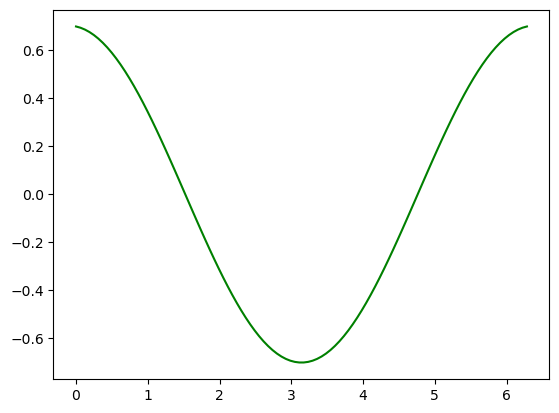

In [4]:
import numpy as numpy
import matplotlib.pyplot as plt

def solve_nonlinear_pendulum(m, alpha, beta, T, max_iterations=100, tolerance=1e-3, verbose=False):
    
    t_bc = numpy.linspace(0.0, T, m + 2)
    t = t_bc[1:-1]
    delta_t = T / (m + 1)
    diagonal = numpy.ones(t.shape)
    G = numpy.empty(t_bc.shape)
    
    theta = 0.7 * numpy.cos(t_bc)
    theta[0] = alpha
    theta[-1] = beta
    
    success = False
    for num_step in range(1, max_iterations):
        
        J = numpy.diag(diagonal * -2.0 / delta_t**2 + numpy.cos(theta[1:-1]), 0)
        J += numpy.diag(diagonal[:-1] / delta_t**2, -1)
        J += numpy.diag(diagonal[:-1] / delta_t**2, 1)
        
        G = (theta[:-2] - 2.0 * theta[1:-1] + theta[2:]) / delta_t**2 + numpy.sin(theta[1:-1])
        
        G[0] = (alpha - 2.0 * theta[1] + theta[2]) / delta_t**2 + numpy.sin(theta[1])
        G[-1] = (theta[-3] - 2.0 * theta[-2] + beta) / delta_t**2 + numpy.sin(theta[-2])
        
        delta = numpy.linalg.solve(J, -G)
        theta[1:-1] += delta
        
        if numpy.linalg.norm(delta) < tolerance:
            success = True
            break
            
    if not success:
        raise ValueError("Reached maximum allowed steps before convergence.")
    
    return t_bc, theta


t, theta = solve_nonlinear_pendulum(100, 0.7, 0.7, 2.0 * numpy.pi, tolerance=1e-9, verbose=False)

plt.plot(t, theta, color='green')
plt.show()

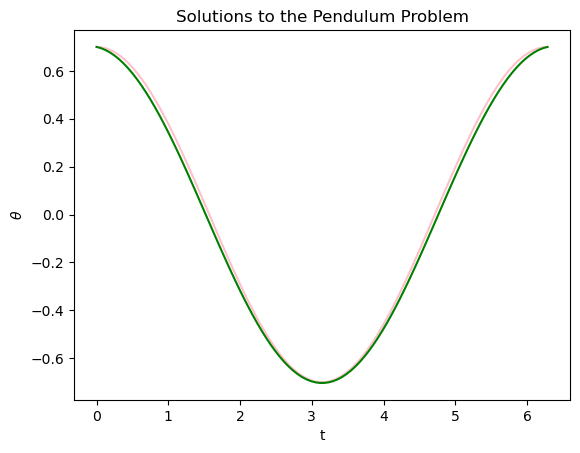

In [6]:
import numpy as numpy
import matplotlib.pyplot as plt

# Linear Problem
alpha = 0.7
beta = 0.7
T = 2.0 * numpy.pi
t = numpy.linspace(0, T, 100)

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Linear solution (pink)
axes.plot(t, linear_pendulum(t, alpha, beta, T), color='pink', label="Linear")

# Non-linear solution (green)
t, theta = solve_nonlinear_pendulum(100, alpha, beta, T)
axes.plot(t, theta, color='green', label="Non-Linear")

axes.set_title("Solutions to the Pendulum Problem")
axes.set_xlabel("t")
axes.set_ylabel(r"$\theta$")

plt.show()

### Akurasi

Perlu dicatat bahwa ada dua gagasan konvergensi yang berbeda dalam solver non-linear kita di atas, yaitu satu adalah konvergensi dari pendekatan beda hingga yang dikendalikan oleh $\Delta x$ dan konvergensi dari iterasi Newton. Kita mengharapkan keduanya memiliki orde kedua (metode Newton konvergen secara kuadratik dengan asumsi yang sesuai). Bagaimana kedua metode ini digabungkan untuk mempengaruhi kesalahan global?


### Menghitung LTE

$$
\begin{aligned}
    \tau_{i} &= \frac{1}{\Delta t^2} (\theta(t_{i+1}) - 2 \theta(t_i) + \theta(t_{i-1})) + \sin \theta(t_i) \\
    &= \frac{1}{\Delta t^2} \left( \theta(t_i) + \theta'(t_i) \Delta t + \frac{1}{2} \theta''(t_i) \Delta t^2 + \frac{1}{6} \theta'''(t_i) \Delta t^3 + \frac{1}{24} \theta^{(4)}(t_i) \Delta t^4 - 2 \theta(t_i) \right. \\
    &\quad \quad \quad \left. + \theta(t_i) - \theta'(t_i) \Delta t + \frac{1}{2} \theta''(t_i) \Delta t^2 - \frac{1}{6} \theta'''(t_i) \Delta t^3 + \frac{1}{24} \theta^{(4)}(t_i) \Delta t^4 + \mathcal{O}(\Delta t^5) \right) + \sin \theta(t_i) \\
    &= \frac{1}{\Delta t^2} \left( \theta''(t_i) \Delta t^2 + \frac{1}{12} \theta^{(4)}(t_i) \Delta t^4 + \mathcal{O}(\Delta t^6) \right) + \sin \theta(t_i) \\
    &= \theta''(t_i) + \sin \theta(t_i) + \frac{1}{12} \theta^{(4)}(t_i) \Delta t^2 + \mathcal{O}(\Delta t^4).
\end{aligned}
$$

Untuk metode Newton, kita dapat mempertimbangkan perbedaan antara langkah dengan solusi sebenarnya untuk masalah nilai batas $\hat{\theta}$ dengan solusi perkiraan $\theta$. Kita dapat merumuskan LTE yang serupa di mana:

$$
    G(\Theta) = 0 \quad G(\hat{\Theta}) = \tau.
$$

Melanjutkan diskusi kita sebelumnya, kita dapat menggunakan dua ekspresi ini untuk menemukan:

$$
    G(\Theta) - G(\hat{\Theta}) = -\tau
$$

Dari sini, kita ingin menurunkan ekspresi untuk kesalahan global $E = \Theta - \hat{\Theta}$.

$$
    G'(\hat{\Theta}) E = -\tau
$$

Maka:

$$
    E = - \left( G'(\hat{\Theta}) \right)^{-1} \tau
$$

Mengikuti pembahasan kita sebelumnya, kita bisa menggunakan dua persamaan ini untuk menemukan:

$$
G(\Theta) - G(\hat{\Theta}) = -\tau
$$

Dari sini, kita ingin menurunkan ekspresi untuk kesalahan global $E = \Theta - \hat{\Theta}$.

Karena $G(\theta)$ tidak linier, kita akan menulis persamaan di atas sebagai deret Taylor untuk menemukan:

$$
G(\Theta) = G(\hat{\Theta}) + J(\hat{\Theta}) E + \mathcal{O}(||E||^2).
$$

Menggunakan ekspresi ini, kita mendapatkan:

$$
J(\hat{\Theta}) E = -\tau + \mathcal{O}(||E||^2).
$$

Dengan mengabaikan suku orde lebih tinggi, kita mendapatkan ekspresi linier untuk $E$ yang dapat kita selesaikan.

Hal ini memotivasi definisi lain tentang kestabilan yang melibatkan Jacobian dari $G$. Metode perbedaan nonlinier $G(\Theta) = 0$ dikatakan *stabil* dalam norma $||\cdot||$ jika matriks $(J_{\Delta t})^{-1}$ terbatasi secara seragam dalam norma tersebut saat $\Delta t \to 0$. Dengan kata lain, terdapat $C$ dan $\Delta t^0$ sedemikian sehingga:

$$
|| (J_{\Delta t})^{-1} || \leq C \quad \forall \Delta t < \Delta t^0.
$$

Dengan pengertian kestabilan dan konsistensi ini ($||\tau|| \to 0$ saat $\Delta t \to 0$), maka metode tersebut konvergen sebagai:

$$
||E_{\Delta t}|| \to 0 \quad \text{seiring dengan} \quad \Delta t \to 0.
$$

Perlu dicatat bahwa kita masih belum dapat menjamin bahwa metode Newton akan konvergen, misalnya, jika dimulai dengan tebakan awal yang buruk, meskipun kita telah menunjukkan konvergensi. Dapat dibuktikan bahwa metode Newton akan konvergen dari tebakan awal yang cukup baik. Selain itu, meskipun metode Newton mungkin memiliki kesalahan akibat pembulatan, ini tidak berarti bahwa kesalahan tersebut akan mengikuti hal yang sama.
